Introduction

Sales Performance Analysis is the process of examining sales data to identify trends, patterns, and business opportunities. This project analyzes Superstore sales data to evaluate regional performance, category performance, customer behavior, and seasonal sales trends. The objective is to generate actionable business insights that can support decision-making and improve overall sales performance.

Dataset Overview

The dataset contains sales transaction records from a retail superstore. It includes information about orders, customers, products, regions, categories, and sales values. After data cleaning, the dataset contained 9,800 records and 20 columns, which were used for analysis.

In [6]:
import pandas as pd

df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [7]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [8]:
df.drop_duplicates(inplace=True)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

df.shape

(9800, 20)

In [10]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Year', 'Month']


In [11]:
total_revenue = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
average_order_value = df.groupby('Order_ID')['Sales'].sum().mean()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.48


KPI Observations

Total Revenue: $2,261,536.78

Total Orders: 4,922

Total Customers: 793

Average Order Value: $459.48

Interpretation
The company generated a total revenue of $2.26 million, indicating strong sales performance.

A total of 4,922 orders were placed by 793 unique customers.

The average order value of $459.48 shows that customers generally place medium-to-high value orders.

The ratio of orders to customers suggests that many customers made repeat purchases, indicating customer retention and loyalty.

In [13]:
import matplotlib.pyplot as plt

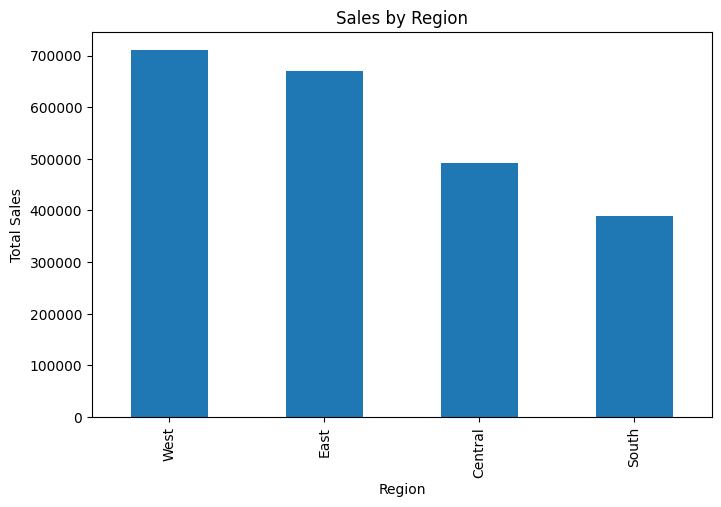

In [14]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


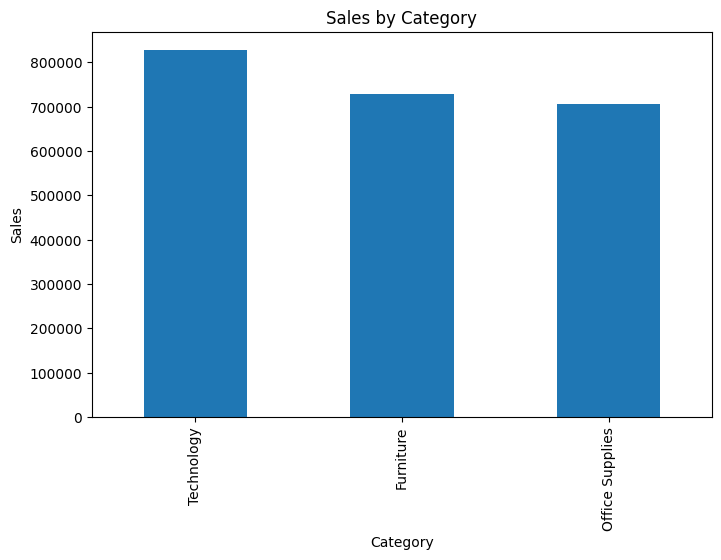

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

Observation – Sales by Category

The Technology category generated the highest sales revenue of $827,455.87,

making it the best-performing category.

Furniture contributed $728,658.58,

 while Office Supplies generated $705,422.33 in sales.

 Although all three categories performed well, Technology clearly leads in revenue generation and should remain a key focus area for the business.

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


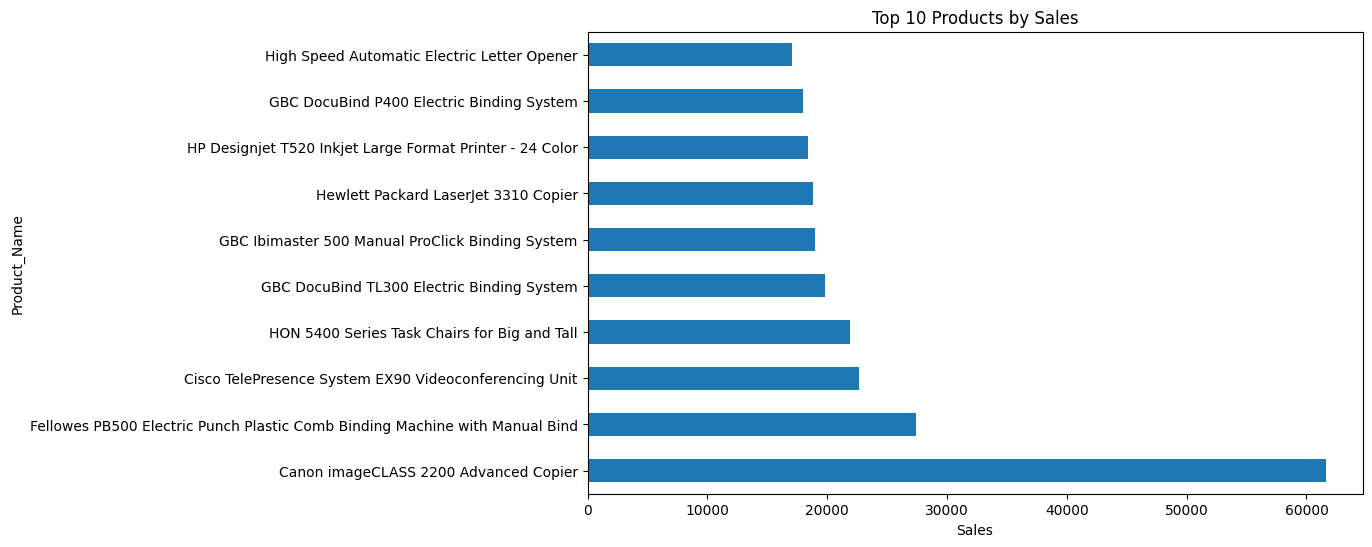

In [16]:
top_products = (
    df.groupby('Product_Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

top_products.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.show()

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


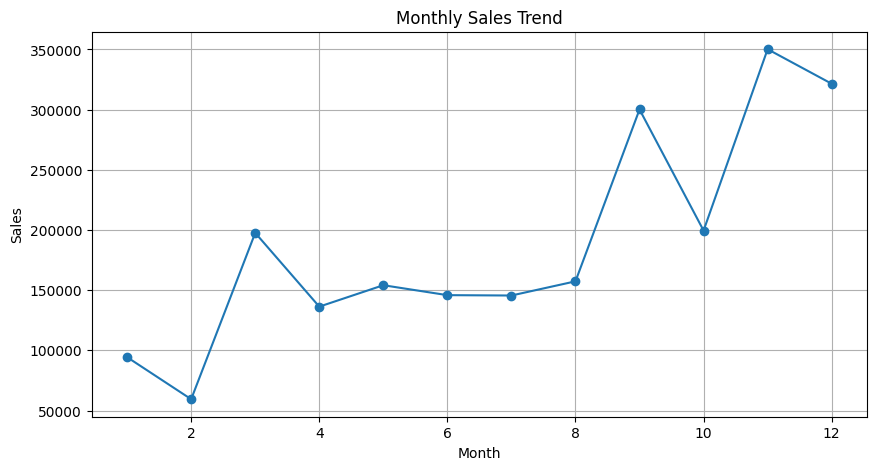

In [17]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

Observation – Monthly Sales Trend

Sales show clear seasonal variations throughout the year.
The lowest sales were recorded in February ($59,371.12),

 while the highest sales occurred in November ($350,161.71),

 followed by December ($321,480.17)

 and

 September ($300,103.41).

 This indicates that customer purchasing activity increases significantly during the last quarter of the year. Businesses can take advantage of this trend by planning promotions, inventory stocking, and marketing campaigns during these high-demand months.

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


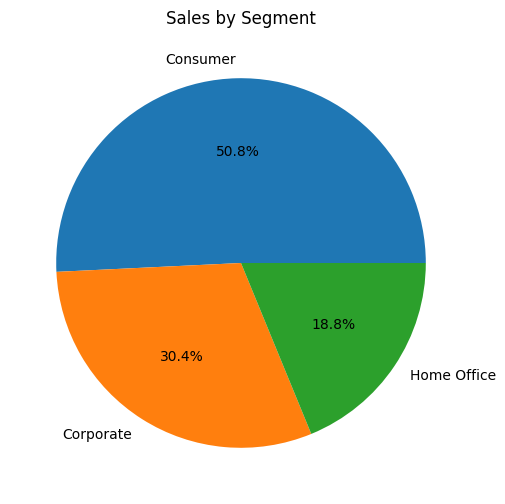

In [18]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

segment_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sales by Segment')
plt.ylabel('')
plt.show()

Observation:

The Consumer segment contributes the largest share of sales, indicating that individual customers are the primary revenue source for the company.

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


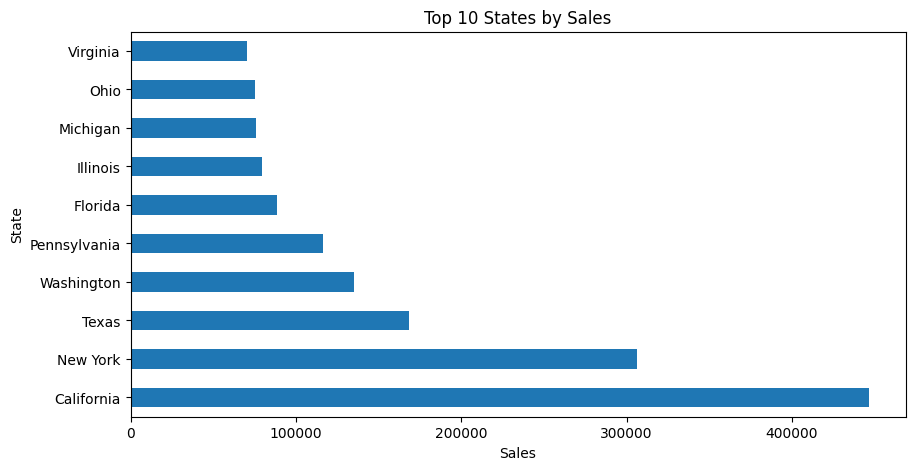

In [19]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

print(state_sales)

state_sales.plot(kind='barh', figsize=(10,5))
plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.show()

Observation:

The top-performing states contribute a significant portion of total revenue and represent important target markets.

Customer_Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


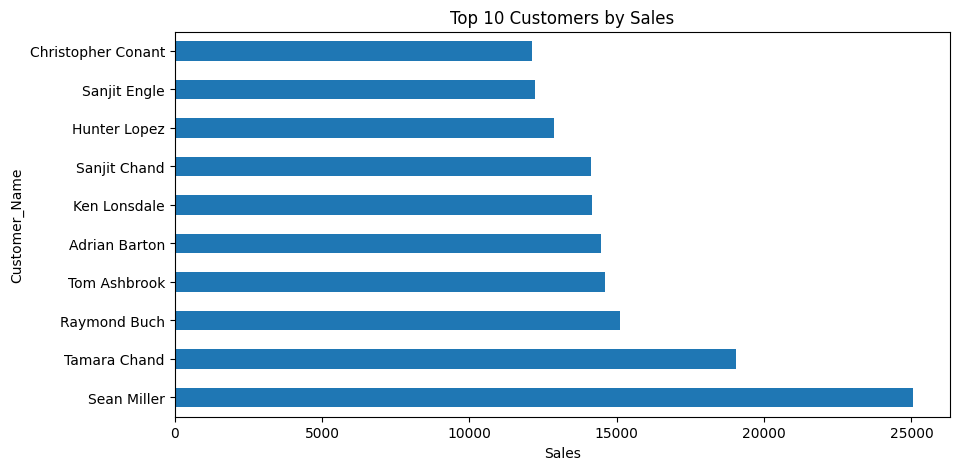

In [20]:
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

top_customers.plot(kind='barh', figsize=(10,5))
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.show()

Observation:

A small group of customers contributes a large amount of revenue, highlighting the importance of customer retention strategies.

 Conclusion

> This Sales Performance Analysis project examined sales data from a retail superstore to identify key business trends and performance patterns. After cleaning and analyzing 9,800 records, the dataset revealed a total revenue of **$2.26 million** generated from **4,922 orders** placed by **793 customers**. The **West region** recorded the highest sales, while **Technology** emerged as the top-performing product category. Product analysis showed that the **Canon imageCLASS 2200 Advanced Copier** was the highest revenue-generating product. Monthly sales analysis indicated strong seasonal demand, with sales peaking during **September, November, and December**. These insights highlight the importance of focusing on high-performing regions, categories, and products while leveraging seasonal trends for strategic planning. Overall, the analysis demonstrates how data-driven decision-making can help improve sales performance, customer engagement, and business growth.
